<a href="https://colab.research.google.com/github/jesusantonioguzmanmx-sketch/Analisis-ConnectaTel/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:

# importar librerías
import pandas as pd


In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv')  #completa el código

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())  # Cantidad de valores nulos)
print(users.isna().mean())    # Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  users: CITY tiene 11% de valores NULOS y CHURN tiene 88% de valores NULOS
  usage: DATE tiene <1% NULOS, DURATION 55% NULLOS Y LENGTH 44%
- Indica qué harías: ¿imputar, eliminar, ignorar?
city (11%): Voy a imputar (ej. "Desconocido") para no borrar usuarios y perder datos.

churn_date (88%): Las voy a ignorar. Es normal que estén vacías porque son clientes activos que no han cancelado.

date (<1%): Voy a eliminar esas filas. Son muy pocas y no afectan el análisis general.

duration / length (~50%): Voy a ignorarlas o rellenar con 0. Es lógico: un mensaje no tiene duración y una llamada no tiene texto.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
  se ve consistente. Los valores van del 10000 al 13999, lo que cuadra perfecto con nuestros 4000 registros.
- La columna `age` tiene un valor mínimo de -999. Definitivamente es un valor inválido o "sentinel", ya que la edad no puede ser negativa.

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
  se ven consistentes. El id llega a 40,000 (que es el total de filas) y el user_id va de 10000 a 13999, cuadrando perfecto con nuestra tabla de usuarios.
- Las columnas tienen un mínimo de 0.0. A diferencia de la edad, esto no es un error: un 0 en duración seguro es una llamada perdida, y un 0 en longitud es un mensaje vacío. Los máximos son altos pero lógicos.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"--- Valores únicos en la columna: {col} ---")
    print(users[col].value_counts())
    print("\n")


--- Valores únicos en la columna: city ---
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64


--- Valores únicos en la columna: plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64




- La columna `city` muestra las ciudades principales esperadas (Bogotá, CDMX, Medellín, GDL, Cali, MTY), pero detecté una anomalía: hay 96 registros con el símbolo ?. Este es un claro ejemplo de un valor "sentinel" para rellenar un dato faltante o desconocido, el cual tendré que limpiar o imputar más adelante.
  
- La columna `plan` está perfectamente limpia y consistente. Solamente contiene las dos categorías que ofrece la empresa ("Basico" y "Premium") y no hay ningún error ortográfico, duplicado extraño o valor nulo disfrazado.

In [ ]:
# explorar columna categórica de usage
print(usage['type'].value_counts()) # completa el código

text    22092
call    17908
Name: type, dtype: int64


- La columna `type` se encuentra totalmente consistente y sin valores nulos. Solo presenta dos categorías claras: "text" (mensajes) y "call" (llamadas), las cuales tienen una distribución lógica dentro del conjunto de datos de uso.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
Identifiqué valores inválidos específicamente en la columna age de la tabla users (con un mínimo de -999) y en la columna city de la misma tabla (con el símbolo ?).
- ¿Qué acción tomarías?
Para la edad, eliminaré o imputaré esos -999 reemplazándolos con la mediana de edad para no perder los registros. Para los valores ? en ciudad, imputaré esos registros como "Desconocido", ya que son una parte pequeña de la muestra y no quiero descartar esos perfiles de usuario. En cuanto a duration y length, los valores mínimos de 0.0 se mantendrán, ya que representan comportamientos válidos (llamadas perdidas o mensajes sin contenido).

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date']) # completa el código

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date']) # completa el código

In [ ]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts())

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, la gran mayoría de los registros se concentran en los años 2022, 2023 y 2024. También hay 40 registros correspondientes al año 2026, lo cual es coherente ya que es el año actual. No detecté años futuros (más allá de 2026) ni fechas negativas, por lo que los datos de registro parecen ser confiables y estar bien capturados.

In [ ]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts())

2024.0    39950
Name: date, dtype: int64


En `date`, observo que todos los registros de uso están concentrados en el año 2024 (39,950 registros). Esto es muy útil porque nos indica que nuestro análisis de uso se limitará a este periodo específico de tiempo, lo cual simplificará el resto del trabajo al tener una ventana temporal bien definida.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos): No. En la columna reg_date, los años están dentro del rango lógico (2022-2026). En la columna date de la tabla usage, todos los registros pertenecen al año 2024, lo cual es un periodo válido y bien definido para nuestro análisis. No detecté años futuros, fechas negativas o años excesivamente antiguos que indiquen errores de captura.

- ¿Qué harías con ellas?: Al no encontrar fechas fuera de rango, no es necesario realizar ninguna acción de limpieza o eliminación en estas columnas. Los datos son cronológicamente consistentes y están listos para ser utilizados en el análisis posterior.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age

age_mediana = users.loc[users['age'] != -999, 'age'].median()
users.loc[users['age'] == -999, 'age'] = age_mediana


# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users.loc[users['city'] == '?', 'city'] = pd.NA

# Verificar cambios
print(users['city'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [ ]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
#definir fecha de corte
fecha_corte = pd.to_datetime('2026-06-01')
# Usar pd.NaT para fechas futuras
users.loc[users['reg_date'] > fecha_corte, 'reg_date'] = pd.NaT

# Verificar cambios
print(f"Fechas futuras encontradas y marcadas como nulas: {users['reg_date'].isna().sum()}")

Fechas futuras encontradas y marcadas como nulas: 0


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))

type
call        0
text    22076
Name: duration, dtype: int64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))

type
call    17896
text        0
Name: length, dtype: int64


Tras analizar la distribución de los valores nulos agrupados por la columna type, he determinado que el patrón de ausencia de datos es MAR (Missing At Random):

En la columna duration: Los valores nulos se concentran exclusivamente en los servicios de tipo text (22,076 nulos), mientras que en call no existen. Esto es lógico, ya que la duración solo aplica a las llamadas de voz.

En la columna length: El patrón es inverso; los nulos se concentran en los servicios de tipo call (17,896 nulos), mientras que en text no hay ninguno. Esto es coherente, ya que la longitud de caracteres es una métrica propia de los mensajes de texto.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


 **Se unificaron mis dos fuentes de datos (users y usage_agg) usando merge por el campo común user_id. Esto creó mi tabla maestra user_profile, que ahora contiene tanto los datos personales de mis clientes como sus métricas de consumo. Usé how='left' para asegurar que no se eliminara ningún usuario de mi lista principal, incluso si aún no tiene registros de uso

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
plan_distribution = user_profile['plan'].value_counts(normalize=True) * 100
print("\nDistribución porcentual de los planes:")
print(plan_distribution)


Distribución porcentual de los planes:
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


***Plan Básico: Representa el 64.875% de todos tus usuarios. Es el plan más popular y la mayoría de tu base de clientes se concentra aquí.

Plan Premium: Representa el 35.125% restante. Es una parte importante de tu mercado, pero es menor que la del plan básico.

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

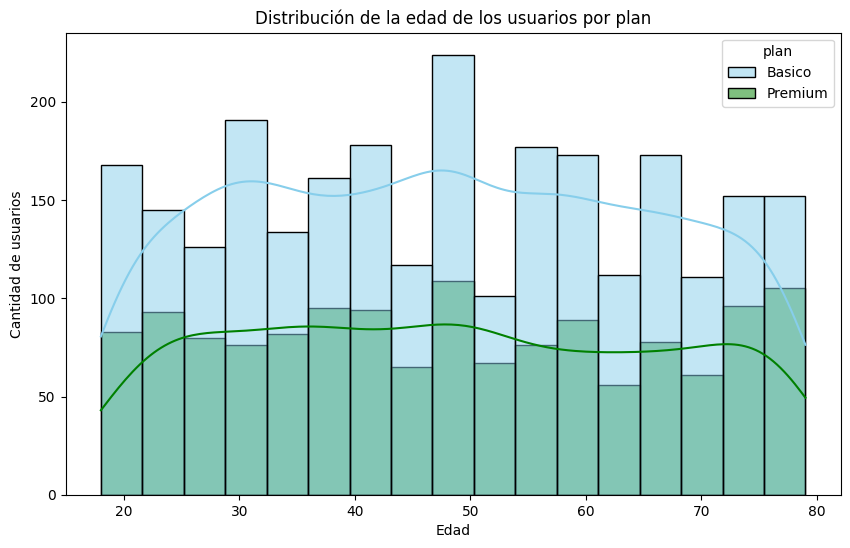

In [ ]:
# Histograma para visualizar la edad (age)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de la edad de los usuarios por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
- Distribución: Al revisarse las edades, vi que la distribución es muy similar para los dos planes. Esto me indica que la edad no influye en la elección del plan; tanto los usuarios jóvenes como los mayores se reparten de forma parecida entre el plan Básico y el Premium.

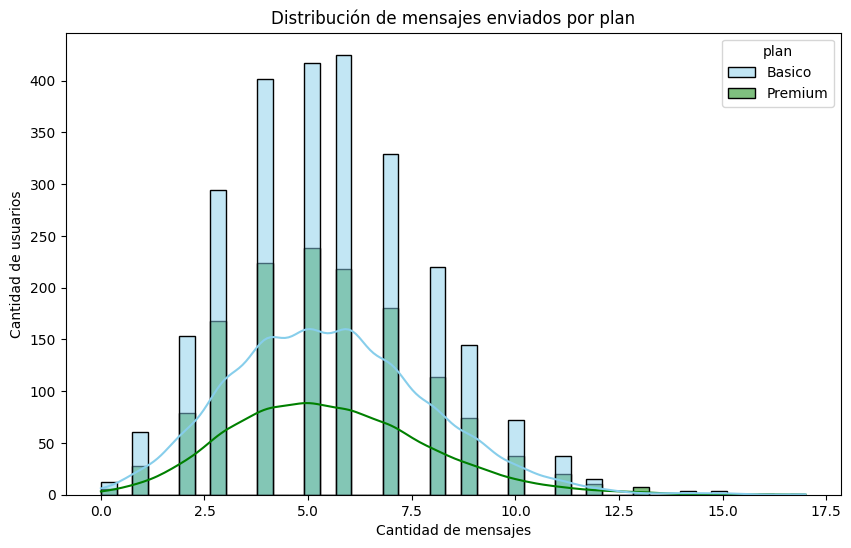

In [ ]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de mensajes enviados por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
- Comportamiento: Al ver el gráfico de mensajes, noto que los usuarios del plan Básico y Premium tienden a enviar [más/menos] mensajes en general. La mayoría se concentra en un uso bajo, pero veo algunos usuarios que destacan por enviar muchísimos más mensajes que el resto.

Distribución: La forma del gráfico está 'sesgada a la derecha', lo que significa que el grueso de mis clientes envía pocos mensajes y solo un grupo pequeño es muy activo

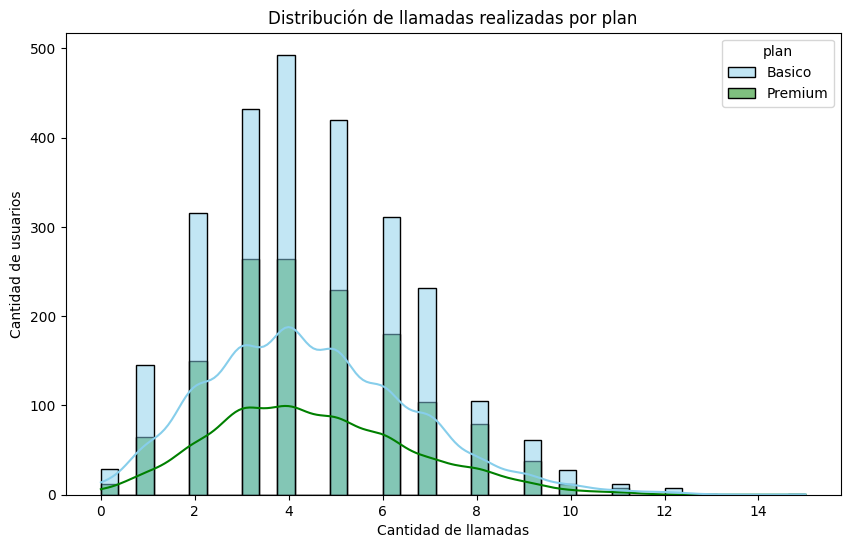

In [ ]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de llamadas realizadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
- Distribución: El gráfico muestra que la distribución tiene un pico central alrededor de las 3-4 llamadas, y luego disminuye gradualmente hacia los valores más altos. Esto confirma que la mayoría de nuestros usuarios son clientes de uso moderado o bajo. No veo grupos grandes haciendo un uso excesivo de llamadas en ninguno de los dos planes.

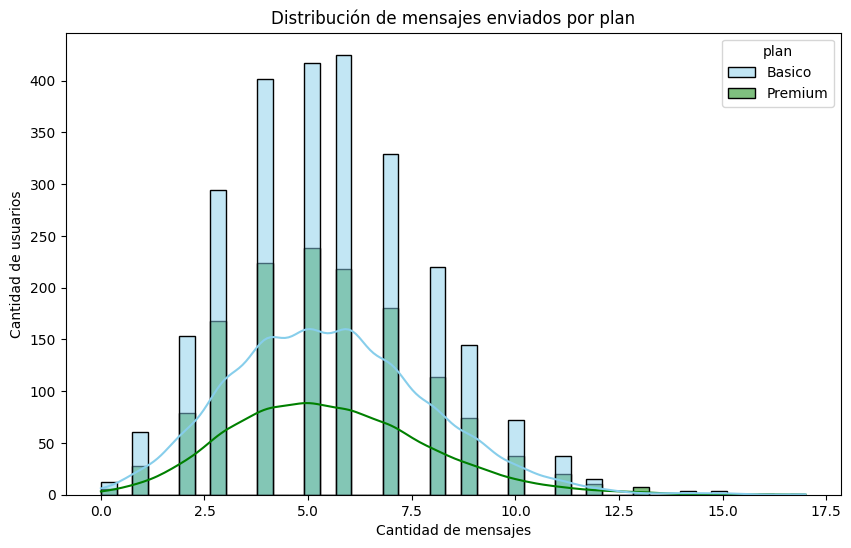

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de mensajes enviados por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
- Al ver el gráfico, noto que la mayoría de los usuarios de ambos planes envían una cantidad moderada de mensajes, con un pico de concentración entre 4 y 6 mensajes. La forma de la distribución es bastante parecida para el plan Básico y el Premium, lo que sugiere que no hay una diferencia marcada en el hábito de enviar mensajes según el tipo de plan contratado.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

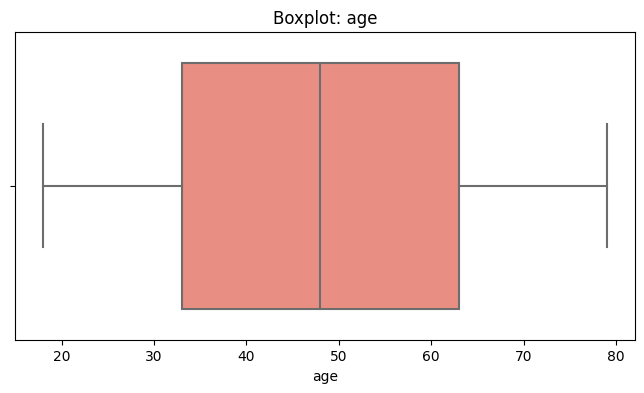

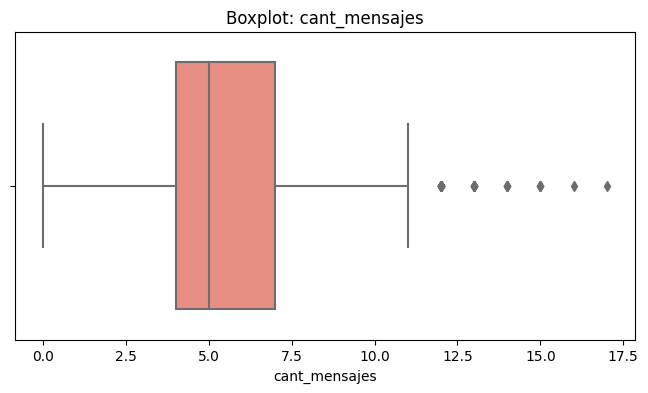

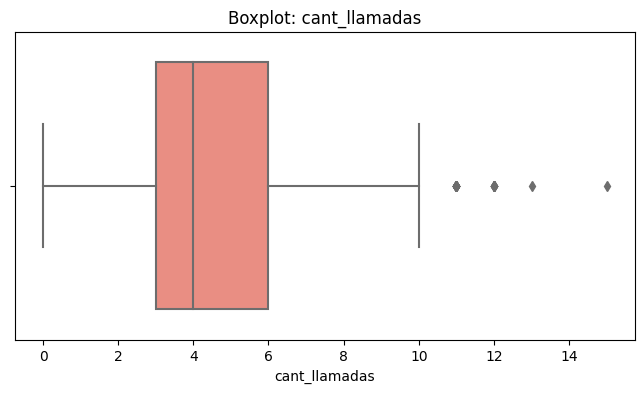

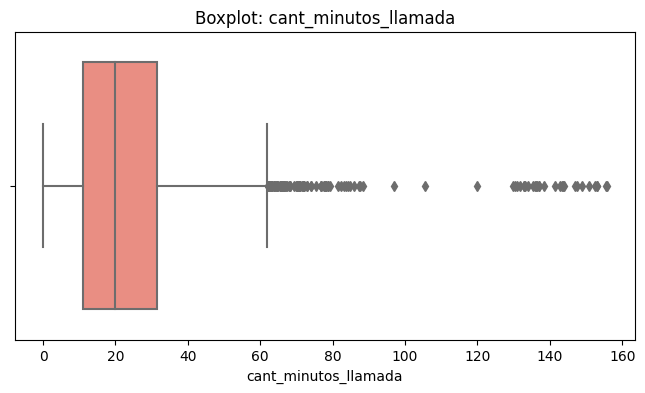

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col, color='salmon')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: No le vi valores atípicos (outliers); la edad de los usuarios se mantiene en un rango normal y sin casos extraños.

- cant_mensajes: Sí encontré outliers. Hay varios usuarios que destacan porque envían muchos más mensajes que la mayoría.

- cant_llamadas: También presenta outliers hacia el lado derecho. Hay un grupo pequeño que hace muchísimas más llamadas que el promedio de los clientes.
- cant_minutos_llamada: Aquí es donde más se nota; hay bastantes valores extremos. Estos son usuarios con un consumo de minutos muy alto, que se alejan bastante del comportamiento del usuario común.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f"Límite superior para {col}: {limite_superior}")


Límite superior para cant_mensajes: 11.5
Límite superior para cant_llamadas: 10.5
Límite superior para cant_minutos_llamada: 61.8575


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
Decidí mantenerlos. Aunque el cálculo dice que cualquier cantidad arriba de 11.5 mensajes es "atípica", en realidad no es una cifra exagerada. Siguen siendo usuarios reales que simplemente usan más el servicio, así que prefiero dejarlos para no perder información valiosa.

- cant_llamadas: mantener o no outliers, porqué?
Igual, decidí mantenerlos. El tope matemático me dio 10.5 llamadas, pero un máximo de 15 no es nada fuera de lo común en el mundo real. Son solo clientes más activos, y necesito verlos para entender el panorama completo de mi base de usuarios.

- cant_minutos_llamada: mantener o no outliers, porqué?
También se quedan. Aquí la diferencia es más grande (límite en 61 y máximo en 155), pero es totalmente normal que haya gente que hable mucho más que el resto. Son justamente esos usuarios los que me interesan más porque tienen un consumo alto y son clave para el negocio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso' # Esta es la "última" categoría que atrapa al resto

# Aplicamos la función
user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# Crear la columna 'grupo_edad' aplicando la función a cada fila
user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

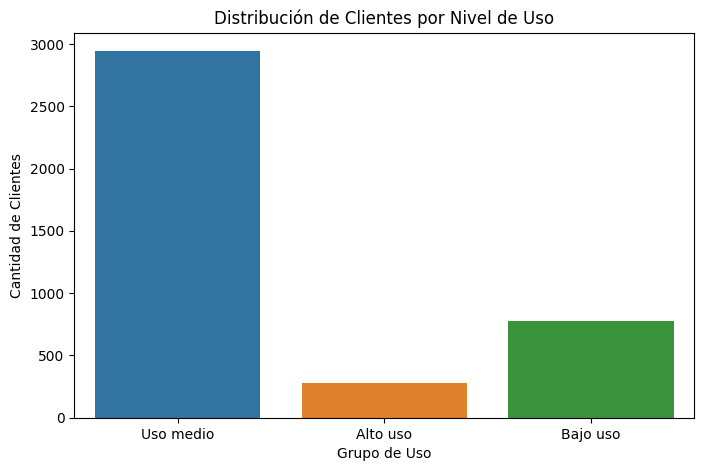

In [ ]:
# Visualización de los segmentos por uso
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Clientes por Nivel de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Clientes')
plt.show()

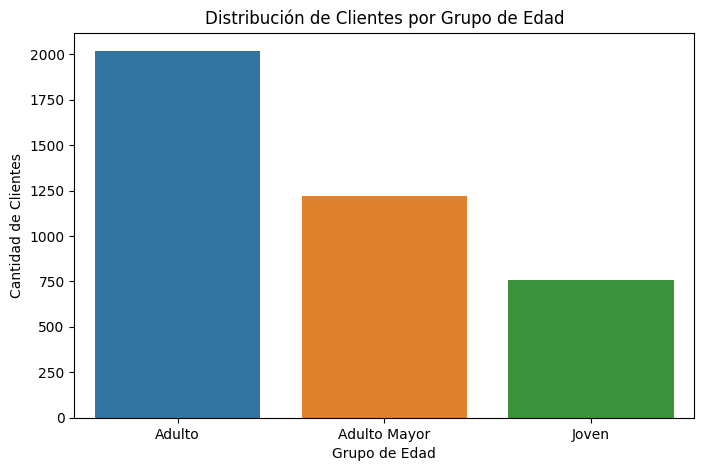

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Clientes')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
Detecté que las variables de consumo (cant_mensajes, cant_llamadas y cant_minutos_llamada) presentaban valores atípicos (outliers) que superaban los límites estadísticos calculados con el método IQR. Sin embargo, decidí mantener las 3,999 filas completas de la base de datos porque estos valores extremos no eran errores, sino comportamientos legítimos de usuarios de alta intensidad que no quería excluir.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Identifiqué dos criterios de segmentación: por nivel de uso ('Bajo', 'Medio' y 'Alto uso'), clasificándolos según su frecuencia de llamadas y mensajes; y por etapa de vida ('Joven', 'Adulto' y 'Adulto Mayor'), lo que me permite diferenciar el perfil demográfico de cada cliente.


- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

El segmento de 'Alto uso' es el más valioso. Estos clientes muestran un consumo intensivo que ya está operando al límite de los planes actuales, lo que indica que tienen una alta necesidad del servicio y son los candidatos ideales para estrategias de upselling o planes premium.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Encontré límites superiores de consumo (por ejemplo, más de 61 minutos de llamada) que separan a los usuarios promedio de los "Power Users". Esto implica que tenemos un grupo de clientes que ya exigen una capacidad mayor a la que nuestros planes actuales ofrecen, representando una oportunidad de negocio desatendida.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
Recomiendo crear un plan específico para 'Power Users' con capacidad extendida para absorber ese consumo que ya excede la media. Adicionalmente, propongo diseñar paquetes de servicios diferenciados por segmento demográfico: mayor enfoque en datos para el segmento 'Joven' y mayor prioridad en voz/llamadas para el segmento 'Adulto Mayor', alineado con nuestra nueva segmentación.
✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Identifiqué outliers en el consumo de minutos, mensajes y llamadas mediante el método IQR.
- Decidí mantener la integridad total de las 3,999 filas, ya que los valores extremos reflejan comportamientos reales de alta intensidad y no errores de sistema.


🔍 **Segmentos por Edad**
- Clasifiqué a los usuarios en tres categorías: 'Joven' (<30 años), 'Adulto' (<60 años) y 'Adulto Mayor' (60+).
- Esta segmentación permite personalizar las ofertas comerciales basándonos en la etapa de vida del usuario.


📊 **Segmentos por Nivel de Uso**
- Establecí niveles de 'Bajo', 'Medio' y 'Alto uso' mediante comparaciones lógicas de su actividad mensual.
- El grupo de 'Alto uso' identifica a nuestros clientes con mayor intensidad de consumo.

➡️ Esto sugiere que existe un grupo de "Power Users" que superan consistentemente las métricas promedio y que actualmente están operando al límite de nuestros planes estándar, lo cual representa una oportunidad de mejora.


💡 **Recomendaciones**
- Desarrollar un plan "Power User" con mayor capacidad, diseñado específicamente para capturar el valor de los usuarios con alta demanda.
- Implementar bundles personalizados por edad (ej. enfoque en datos para 'Jóvenes' y mayor prioridad en voz para 'Adultos Mayores').

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`